In [1]:
# Wolfram Language Imports
from wolframclient.evaluation import WolframLanguageSession
from wolframclient.language import wl, wlexpr
ws = WolframLanguageSession()

In [2]:
# Display Latex
from IPython.display import display, Math

# Display Plots
%matplotlib notebook
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [3]:
def print_tex(expr):
    """Prints an expression in latex"""
    display(Math(expr))

def print_wlresult(expr):
    """Prints a wolfram language result in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(expr)))
    display(Math(tex_expr))

def print_wlexpr(expr):
    """Prints a wolfram language expression in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(ws.evaluate(expr))))
    display(Math(tex_expr))
    
def wc(expr):
    """Evaluates an expression, stores, and prints the result"""
    result = ws.evaluate(expr)
    save_expr_str = 'rrr = {}'.format(expr)
    ws.evaluate(save_expr_str)
    print_wlresult(ws.evaluate('rrr'))
    return result

def wplot(filename, command):
    export_expr = 'Export["{}", {}]'.format(filename, command)
    wc(export_expr)
    fig, ax = plt.subplots(figsize=(7, 5))
    img = mpimg.imread(filename)
    ax.imshow(img)
    ax.axis('off')
    

print('\nPrinting latex:')
print_tex('\sum_{i=1}^{10} x_i')

print('\nPrinting the result of an evaluated expression:')
print_wlresult(ws.evaluate('x+2+y+3'))

print('\nEvaluating and printing an expression directly:')
print_wlexpr('Sum[x^k, {k, 0, 5}]')

print('\nEvaluating, storing, and printing reults:')
wc('Sum[x^k, {k, 0, 5}]')

print('\nAccessing those results in the variable "rrr":')
wc('rrr*10 + y')


Printing latex:


<IPython.core.display.Math object>


Printing the result of an evaluated expression:


<IPython.core.display.Math object>


Evaluating and printing an expression directly:


...


Evaluating, storing, and printing reults:


<IPython.core.display.Math object>


Accessing those results in the variable "rrr":


<IPython.core.display.Math object>

Plus[Times[10, Plus[1, Global`x, << 2 >>, Power[Global`x, 4], Power[Global`x, 5]]], Global`y]

In [4]:
wc('''
FullSimplify[Sech[(Pi/2) x] Cos[x v] == (E^((Pi x)/2) (E^(-(I v x)) + E^(I v x)))/(1 + E^(Pi x))]
''')

<IPython.core.display.Math object>

True

In [5]:
wc('''
FullSimplify[Sech[(Pi/2) x] Cos[x v] == E^((Pi x)/2) E^(-(I v x))/(1 + E^(Pi x)) + E^((Pi x)/2) E^(I v x)/(1 + E^(Pi x))]
''')

<IPython.core.display.Math object>

True

In [6]:
wc('''
FullSimplify[Sech[x Pi / 2] Cos[x v] == Exp[Pi x / 2] * Exp[-I v x] / (1 + Exp[Pi x]) + Exp[Pi x / 2] Exp[I v x] / (1 + Exp[Pi x])]
''')

<IPython.core.display.Math object>

True

In [7]:
wc('''
Integrate[Exp[Pi x / 2] Exp[-I v x] / (1 + Exp[Pi x]), {x, S, Infinity}]
''')

<IPython.core.display.Math object>

ConditionalExpression[Plus[Times[-2, Power[E, Times[Rational[1, 2], Global`S, Plus[Pi, Times[Complex[0, -2], Global`v]]]], Power[Plus[Pi, Times[Complex[0, -2], Global`v]], -1], Hypergeometric2F1[1, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Times[-1, Power[E, Times[Pi, Global`S]]]]], Sech[Global`v]], Less[Times[2, Im[Global`v]], Pi]]

In [8]:
wc('''
Integrate[Exp[Pi x / 2] Exp[I v x] / (1 + Exp[Pi x]), {x, S, Infinity}]
''')

<IPython.core.display.Math object>

ConditionalExpression[Plus[Times[-2, Power[E, Times[Rational[1, 2], Global`S, Plus[Pi, Times[Complex[0, 2], Global`v]]]], Power[Plus[Pi, Times[Complex[0, 2], Global`v]], -1], Hypergeometric2F1[1, Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]], Plus[Rational[3, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]], Times[-1, Power[E, Times[Pi, Global`S]]]]], Sech[Global`v]], Greater[Plus[Pi, Times[2, Im[Global`v]]], 0]]

In [9]:
wc('''
rrr1 = FullSimplify[1/Pi * (Exp[Pi*S])^(1/2 + I*v/Pi)/Gamma[1/2 + I*v/Pi]*MeijerG[{{0, 1 - (1/2 + I*v/Pi)}, {}}, {{0, 0}, {}}, 1 + Exp[Pi*S]]]
''')

<IPython.core.display.Math object>

Times[Power[Plus[1, Power[E, Times[Pi, Global`S]]], Plus[-1, Times[Complex[0, -1], Power[Pi, -1], Global`v]]], Power[Plus[1, Times[-1, Power[Plus[1, Power[E, Times[Pi, Global`S]]], -1]]], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Power[Plus[Pi, Times[Complex[0, -2], Global`v]], -1], Plus[Times[-2, Power[Power[E, Times[Pi, Global`S]], Plus[Rational[1, 2], Times[Complex[0, 2], Power[Pi, -1], Global`v]]], Hypergeometric2F1[1, 1, Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Power[Plus[1, Power[E, Times[Pi, Global`S]]], -1]]], Times[Power[Power[E, Times[Pi, Global`S]], Times[Complex[0, 1], Power[Pi, -1], Global`v]], Plus[1, Power[E, Times[Pi, Global`S]]], Plus[Pi, Times[Complex[0, -2], Global`v]], Sech[Global`v]]]]

In [10]:
wc('''
rrr2 = Simplify[1/Pi * Exp[Pi*S]^(1/2 - I*v/Pi)/Gamma[1/2 - I*v/Pi]*MeijerG[{{0, 1 - (1/2 - I*v/Pi)}, {}}, {{0, 0}, {}}, 1 + Exp[Pi*S]]]
''')

<IPython.core.display.Math object>

Times[Power[Plus[1, Power[E, Times[Pi, Global`S]]], -1], Plus[1, Power[E, Times[Pi, Global`S]], Times[-1, Power[Power[E, Times[Pi, Global`S]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]], Power[Gamma[Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]], -1], Hypergeometric2F1Regularized[1, 1, Plus[Rational[3, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]], Power[Plus[1, Power[E, Times[Pi, Global`S]]], -1]]]], Sech[Global`v]]

In [11]:
wc('''
qqq = FullSimplify[rrr1 + rrr2]
''')

<IPython.core.display.Math object>

Times[2, Plus[Times[Power[Power[E, Times[Pi, Global`S]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]], Power[Plus[1, Power[E, Times[Pi, Global`S]]], -1], Plus[Times[-1, Power[Power[E, Times[Pi, Global`S]], Times[Complex[0, 2], Power[Pi, -1], Global`v]], Power[Plus[Pi, Times[Complex[0, -2], Global`v]], -1], Hypergeometric2F1[1, 1, Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Power[Plus[1, Power[E, Times[Pi, Global`S]]], -1]]], Times[-1, Power[Plus[Pi, Times[Complex[0, 2], Global`v]], -1], Hypergeometric2F1[1, 1, Plus[Rational[3, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]], Power[Plus[1, Power[E, Times[Pi, Global`S]]], -1]]]]], Sech[Global`v]]]

<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


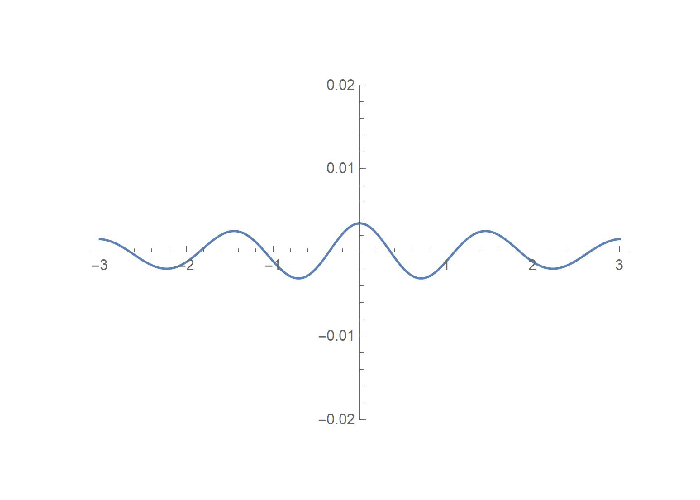

In [12]:
wplot("test1.jpg", '''
M = 3;
S = (Factorial[2M + 2])^(1/(2M+2));
Plot[
{NIntegrate[Sech[Pi x / 2] Cos[v x], {x, S, 100}]}
, {v, -3, 3}, PlotRange -> {-0.02,0.02}]
''')

<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


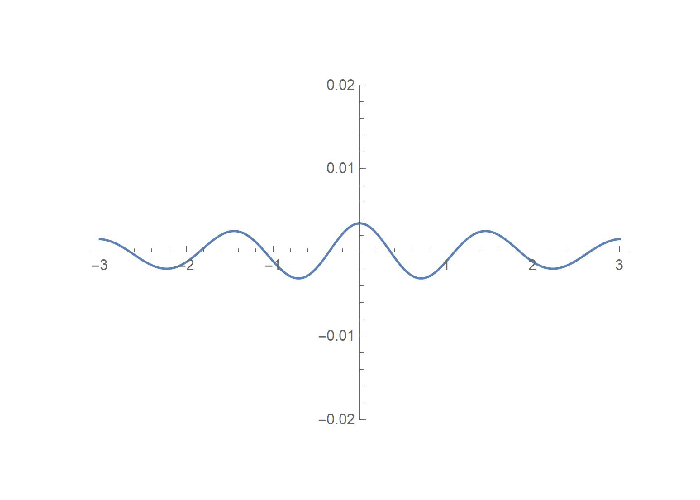

In [13]:
wplot("test2.jpg", '''
M = 3;
S = (Factorial[2M + 2])^(1/(2M+2));
Plot[
{
2*Sech[v] 
-(1/Pi) (Exp[Pi*S]^(1/2 + I*v/Pi)/Gamma[1/2 + I*v/Pi]*MeijerG[{{0, 1/2 - I*v/Pi}, {}}, {{0, 0}, {}}, 1 + Exp[Pi*S]]
       + Exp[Pi*S]^(1/2 - I*v/Pi)/Gamma[1/2 - I*v/Pi]*MeijerG[{{0, 1/2 + I*v/Pi}, {}}, {{0, 0}, {}}, 1 + Exp[Pi*S]])
}
, {v, -3, 3}, PlotRange -> {-0.02,0.02}]
''')

In [14]:
wc('ClearAll[v,S]')
wc('''
rrr1 = FullSimplify[1/Pi * (Exp[Pi*S])^(1/2 + I*v/Pi)/Gamma[1/2 + I*v/Pi]*MeijerG[{{0, 1/2 - I*v/Pi}, {}}, {{0, 0}, {}}, 1 + Exp[Pi*S]]]
''')
wc('''
rrr2 = Simplify[1/Pi * Exp[Pi*S]^(1/2 - I*v/Pi)/Gamma[1/2 - I*v/Pi]*MeijerG[{{0, 1/2 + I*v/Pi}, {}}, {{0, 0}, {}}, 1 + Exp[Pi*S]]]
''')
wc('''
qqq = FullSimplify[rrr1 + rrr2]
''')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Times[2, Plus[Times[Power[Power[E, Times[Pi, Global`S]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]], Power[Plus[1, Power[E, Times[Pi, Global`S]]], -1], Plus[Times[-1, Power[Power[E, Times[Pi, Global`S]], Times[Complex[0, 2], Power[Pi, -1], Global`v]], Power[Plus[Pi, Times[Complex[0, -2], Global`v]], -1], Hypergeometric2F1[1, 1, Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Power[Plus[1, Power[E, Times[Pi, Global`S]]], -1]]], Times[-1, Power[Plus[Pi, Times[Complex[0, 2], Global`v]], -1], Hypergeometric2F1[1, 1, Plus[Rational[3, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]], Power[Plus[1, Power[E, Times[Pi, Global`S]]], -1]]]]], Sech[Global`v]]]

<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


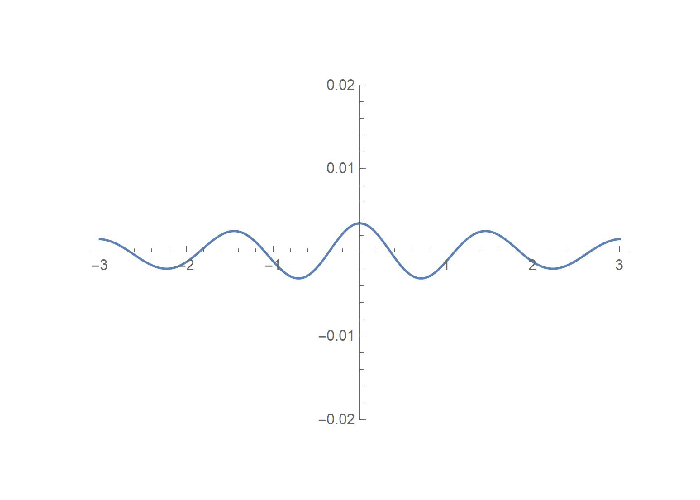

In [15]:
wplot("test3.jpg", '''
M = 3;
S = (Factorial[2M + 2])^(1/(2M+2));
Plot[
{
2*Sech[v] - qqq
}
, {v, -3, 3}, PlotRange -> {-0.02,0.02}]
''')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


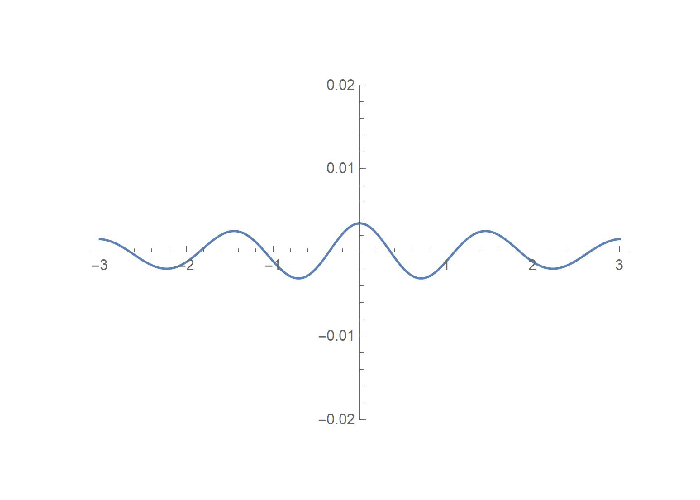

In [31]:
wc('ClearAll[v,S]')
wplot("test4.jpg", '''
M = 3;
S = (Factorial[2M + 2])^(1/(2M+2));
Plot[
{Exp[Pi*S]^(1/2 + I*v/Pi) / ((Exp[Pi*S] + 1)*(Pi/2 - I*v))*Hypergeometric2F1[1, 1, 3/2-I*v/Pi, 1/(1 + Exp[Pi*S])]
+ Exp[Pi*S]^(1/2 - I*v/Pi) / ((Exp[Pi*S] + 1)*(Pi/2 + I*v))*Hypergeometric2F1[1, 1, 3/2+I*v/Pi, 1/(1 + Exp[Pi*S])]
}
, {v, -3, 3}, PlotRange -> {-0.02,0.02}]
''')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


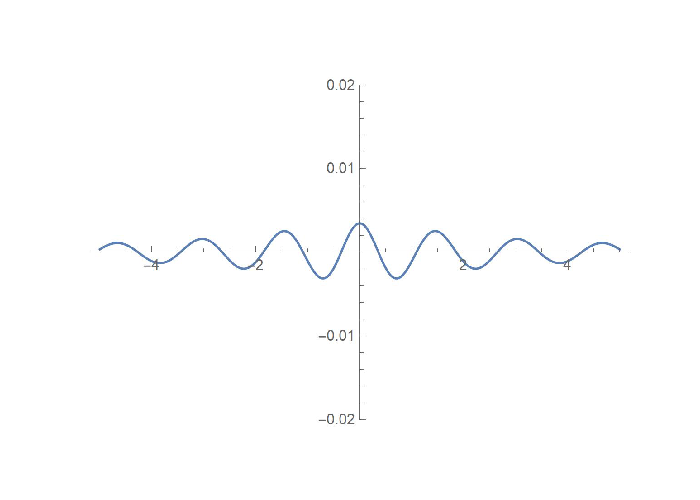

In [38]:
wc('ClearAll[v,S]')
wplot("test5.jpg", '''
M = 3;
S = (Factorial[2M + 2])^(1/(2M+2));
Plot[
{Exp[Pi*S]^(1/2 + I*v/Pi) / ((Exp[Pi*S] + 1)*(Pi/2 - I*v)) + Exp[Pi*S]^(1/2 - I*v/Pi) / ((Exp[Pi*S] + 1)*(Pi/2 + I*v))
}
, {v, -5, 5}, PlotRange -> {-0.02,0.02}]
''')

In [34]:
wc('ClearAll[v,S]')
wc('''
FullSimplify[
Exp[Pi*S]^(1/2 + I*v/Pi) / ((Exp[Pi*S] + 1)*(Pi/2 - I*v)) + Exp[Pi*S]^(1/2 - I*v/Pi) / ((Exp[Pi*S] + 1)*(Pi/2 + I*v))
]
''')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Times[2, Power[Power[E, Times[Pi, Global`S]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]], Power[Plus[1, Power[E, Times[Pi, Global`S]]], -1], Plus[Times[Power[Power[E, Times[Pi, Global`S]], Times[Complex[0, 2], Power[Pi, -1], Global`v]], Power[Plus[Pi, Times[Complex[0, -2], Global`v]], -1]], Power[Plus[Pi, Times[Complex[0, 2], Global`v]], -1]]]

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


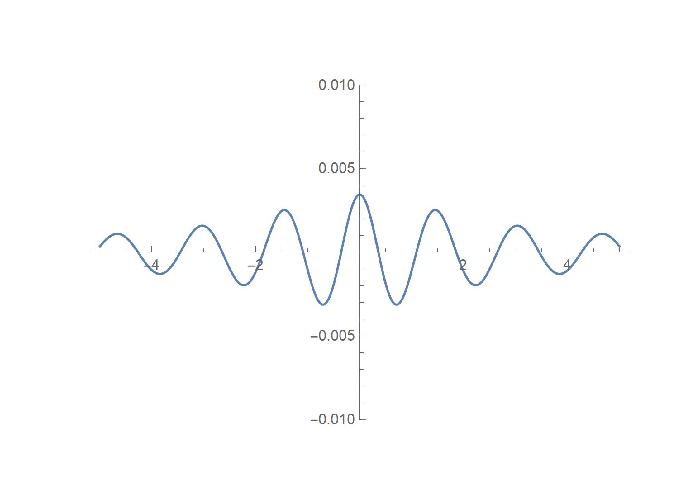

In [46]:
wc('ClearAll[v,S]')
wplot("test5.jpg", '''
M = 3;
S = (Factorial[2M + 2])^(1/(2M+2));
Plot[
{
Exp[Pi*S/2] / (Exp[Pi*S] + 1) * (Exp[I*S*v]/(Pi/2 - I*v) + Exp[-I*S*v]/(Pi/2 + I*v))
}
, {v, -5, 5}, PlotRange -> {-0.01,0.01}]
''')

In [42]:
wc('ClearAll[v,S]')
wc('''
FullSimplify[Exp[I*S*v]/(Pi/2-I*v) + Exp[-I*S*v]/(Pi/2+I*v)]
''')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Times[Power[Plus[Power[Pi, 2], Times[4, Power[Global`v, 2]]], -1], Plus[Times[4, Pi, Cos[Times[Global`S, Global`v]]], Times[-8, Global`v, Sin[Times[Global`S, Global`v]]]]]

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


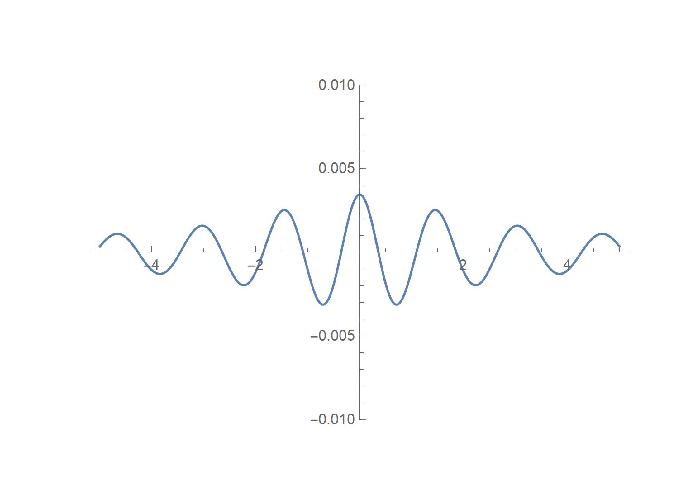

In [45]:
wc('ClearAll[v,S]')
wplot("test5.jpg", '''
M = 3;
S = (Factorial[2M + 2])^(1/(2M+2));
Plot[
{
4*Exp[Pi*S/2]/((Exp[Pi*S]+1)*(4*v^2+Pi^2))*(Pi*Cos[S*v]-2*v*Sin[S*v])
}
, {v, -5, 5}, PlotRange -> {-0.01,0.01}]
''')

In [48]:
ws.stop()